## Clasificarea automată a produselor pe categorii
# Alexandru Popovici


Scopul acestui notebook este să analizăm setul de date `products.csv`, să-l curățăm, să testăm și să comparăm mai mulți algoritmi de clasificare text, și să alegem modelul final care va fi salvat și folosit în `train_model.py` / `predict_category.py`.

# Încărcare și explorare date
Incarc setul brut și vizualizez structura lui: câte rânduri/coloane avem, ce tipuri de date conțin și dacă există valori lipsă.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("products.csv")
df

,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023
...,...,...,...,...,...,...,...,...
35306,47350,smeg fab28 60cm retro style right hand hinge f...,59,Fridges,XC-7600-CL,1512.0,5.0,12/11/2022
35307,47351,smeg fab28 60cm retro style left hand hinge fr...,59,Fridges,KO-8128-SA,2923.0,3.7,5/28/2024
35308,47352,smeg fab28 60cm retro style left hand hinge fr...,59,Fridges,GI-5721-YO,808.0,1.3,5/29/2023
35309,47355,candy 60cm built under larder fridge cru160nek,125,Fridges,DX-2556-VB,4694.0,3.4,8/2/2024


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  str    
 2   Merchant ID      35311 non-null  int64  
 3    Category Label  35267 non-null  str    
 4   _Product Code    35216 non-null  str    
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7    Listing Date    35252 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.2 MB


# Verificare valori lipsă
Verific câte valori lipsesc pe fiecare coloană, pentru a decide cum tratăm datele incomplete.

In [5]:
df.isna().sum()

product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64

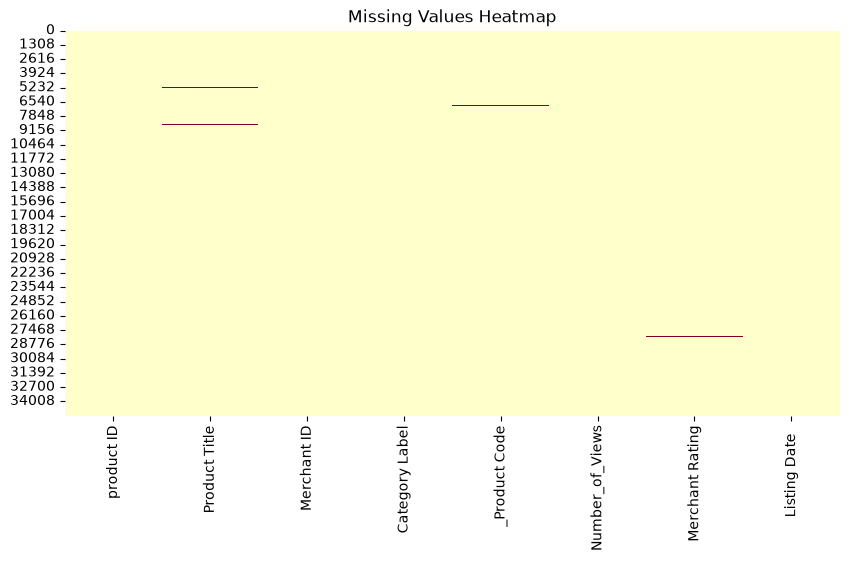

In [6]:
import seaborn as sns 
import matplotlib.pyplot as plt 
 
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

# Curățarea datelor
Am eliminat rândurile fără `Product Title` sau fără `Category Label`, deoarece acestea sunt esențiale pentru antrenarea modelului — un exemplu fără titlu sau fără etichetă nu poate fi folosit la clasificare text. Celelalte coloane (rating, dată listare etc.) nu sunt critice pentru acest task, deci nu impunem `dropna` pe ele.

In [7]:
df = df.dropna(subset= ["Product Title", " Category Label"])

In [8]:
df.isna().sum()

product ID           0
Product Title        0
Merchant ID          0
 Category Label      0
_Product Code       94
Number_of_Views     14
Merchant Rating    170
 Listing Date       58
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 35096 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35096 non-null  int64  
 1   Product Title    35096 non-null  str    
 2   Merchant ID      35096 non-null  int64  
 3    Category Label  35096 non-null  str    
 4   _Product Code    35002 non-null  str    
 5   Number_of_Views  35082 non-null  float64
 6   Merchant Rating  34926 non-null  float64
 7    Listing Date    35038 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 2.4 MB


# Standardizarea etichetelor de categorie
La o primă inspecție a valorilor unice din `Category Label`, am observat etichete duplicate cauzate de inconsistențe de formatare (ex: `Mobile Phone` vs `Mobile Phones`, `CPU` vs `CPUs`, `fridge` vs `Fridges`). Le-am standardizat, altfel modelul ar învăța clase artificiale în plus, ceea ce ar afecta atât acuratețea cât și interpretarea rezultatelor.

In [10]:
df[" Category Label"].unique()

<StringArray>
[   'Mobile Phones',     'Mobile Phone',              'TVs',
             'CPUs',              'CPU',  'Digital Cameras',
       'Microwaves',      'Dishwashers', 'Washing Machines',
         'Freezers',  'Fridge Freezers',          'Fridges',
           'fridge']
Length: 13, dtype: str

In [11]:
df[" Category Label"] = df[" Category Label"].replace({"Mobile Phone" : "Mobile Phones",
                                                       "CPU" : "CPUs",
                                                       "fridge" : "Fridges"})


In [12]:
df[" Category Label"].unique()

<StringArray>
[   'Mobile Phones',              'TVs',             'CPUs',
  'Digital Cameras',       'Microwaves',      'Dishwashers',
 'Washing Machines',         'Freezers',  'Fridge Freezers',
          'Fridges']
Length: 10, dtype: str

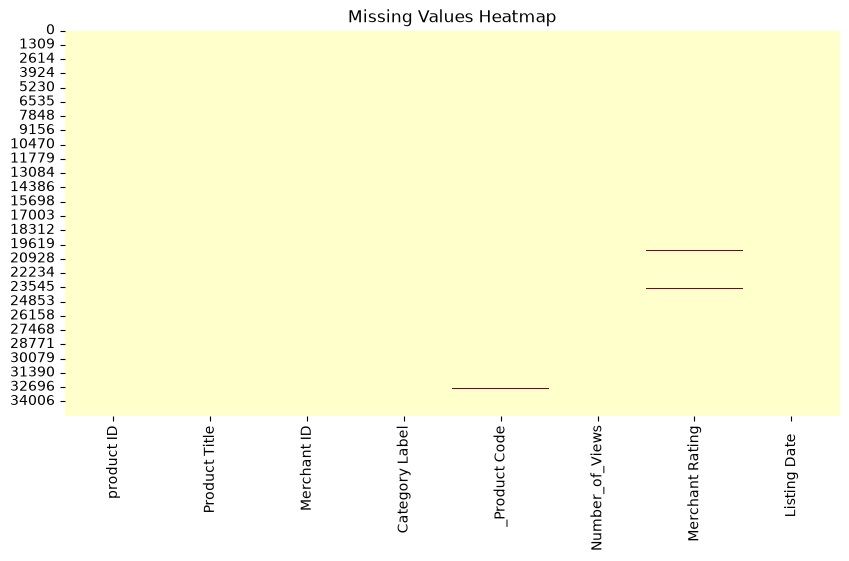

In [13]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

In [14]:
df.sample()

,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
27400,38567,siemens iq 300 free standing fridge freezer fr...,31,Fridge Freezers,IJ-0557-SK,4146.0,4.6,9/24/2024


In [15]:
df.keys()

Index(['product ID', 'Product Title', 'Merchant ID', ' Category Label',
       '_Product Code', 'Number_of_Views', 'Merchant Rating',
       ' Listing Date  '],
      dtype='str')

# Adaugarea unor coloane pentru ingineria caracteristicilor
    - numărul de cuvinte sau caractere din titlu;
    - prezența numerelor sau a caracterelor speciale;
    - dacă titlul conține numele brandului sau toate majusculele (USB, LED…);
    - lungimea celui mai lung cuvânt…

In [16]:
df["title_len_chars"] = df["Product Title"].str.len()
df["title_len_words"] = df["Product Title"].str.split().str.len()
df["has_digit"] = df["Product Title"].str.contains(r"\d", regex=True).astype(int)
df["has_upper_acronym"] = df["Product Title"].str.contains(r"\b[A-Z]{2,}\b", regex=True).astype(int)
df["longest_word_len"] = df["Product Title"].str.split().apply(lambda w: max(len(x) for x in w))

# Eliminarea coloanelor irelevante pentru clasificare text
Am decis sa pastrez doar `Product Title` și `Category Label`. Coloane precum `product ID`, `Merchant ID`, `_Product Code`, `Number_of_Views`, `Merchant Rating` sau `Listing Date` nu au legătură directă cu textul titlului și nu sunt necesare pentru acest model (bazat exclusiv pe text).

In [17]:
df = df.drop(columns=['product ID', 'Merchant ID', '_Product Code', 'Number_of_Views', 'Merchant Rating', 
                      ' Listing Date  '])

In [18]:
df.to_csv("products_clean.csv")

In [19]:
new_df = pd.read_csv("products_clean.csv")

In [20]:
columns = ["Product Title", "title_len_chars", "title_len_words", "has_digit","has_upper_acronym", "longest_word_len"]

# Pregătirea datelor pentru modelare
`X` (features) și `Y` (eticheta țintă — categoria) pornind de la setul curățat.

In [21]:
X = new_df[columns]
Y = new_df[" Category Label"]

In [22]:
from sklearn.model_selection import train_test_split

Am impartit datele în set de antrenare și set de testare (80% / 20%), folosind `stratify=Y` pentru a păstra aceleași proporții ale categoriilor în ambele seturi — important având în vedere că unele categorii (ex: `Microwaves`, `Freezers`) au mai puține exemple decât altele.

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, random_state=42, stratify=Y)

# Evaluarea si compararea mai multor modele pentru a vedea care este cel mai performant

Am inceput prin a completa importul de biblioteci

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

In [25]:
lista_modele = [LogisticRegression(), MultinomialNB(), DecisionTreeClassifier(), RandomForestClassifier(), LinearSVC()]

Testul propriu-zis si rezultatele in ceea ce priveste acuratetea modelelor si compararea acestora intre ele

Acuratetea pentru LogisticRegression() este: 0.960968660968661
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      0.99       766
 Digital Cameras       1.00      0.99      1.00       538
     Dishwashers       0.92      0.97      0.95       681
        Freezers       0.99      0.93      0.96       440
 Fridge Freezers       0.96      0.94      0.95      1094
         Fridges       0.89      0.91      0.90       712
      Microwaves       0.99      0.95      0.97       466
   Mobile Phones       0.98      0.99      0.99       812
             TVs       0.97      0.99      0.98       708
Washing Machines       0.95      0.95      0.95       803

        accuracy                           0.96      7020
       macro avg       0.96      0.96      0.96      7020
    weighted avg       0.96      0.96      0.96      7020



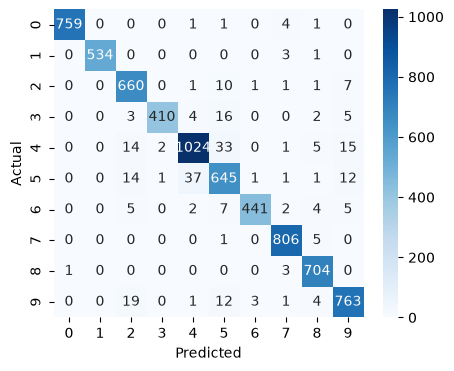

Acuratetea pentru MultinomialNB() este: 0.9149572649572649
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       766
 Digital Cameras       1.00      0.99      0.99       538
     Dishwashers       0.98      0.93      0.95       681
        Freezers       0.99      0.33      0.49       440
 Fridge Freezers       0.70      0.99      0.82      1094
         Fridges       0.88      0.79      0.84       712
      Microwaves       0.99      0.94      0.96       466
   Mobile Phones       0.99      0.99      0.99       812
             TVs       0.98      0.99      0.99       708
Washing Machines       0.99      0.96      0.97       803

        accuracy                           0.91      7020
       macro avg       0.95      0.89      0.90      7020
    weighted avg       0.93      0.91      0.91      7020



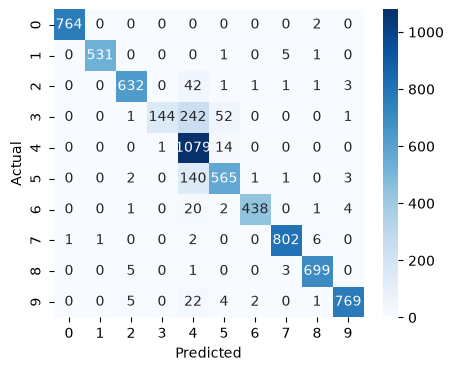

Acuratetea pentru DecisionTreeClassifier() este: 0.9484330484330484
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      0.99       766
 Digital Cameras       0.99      0.99      0.99       538
     Dishwashers       0.94      0.95      0.95       681
        Freezers       0.90      0.92      0.91       440
 Fridge Freezers       0.93      0.93      0.93      1094
         Fridges       0.87      0.87      0.87       712
      Microwaves       0.97      0.95      0.96       466
   Mobile Phones       0.95      0.99      0.97       812
             TVs       0.99      0.98      0.99       708
Washing Machines       0.95      0.92      0.94       803

        accuracy                           0.95      7020
       macro avg       0.95      0.95      0.95      7020
    weighted avg       0.95      0.95      0.95      7020



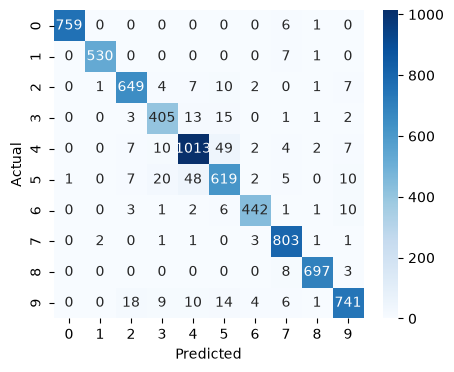

Acuratetea pentru RandomForestClassifier() este: 0.958974358974359
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       766
 Digital Cameras       1.00      0.99      0.99       538
     Dishwashers       0.95      0.95      0.95       681
        Freezers       0.91      0.94      0.92       440
 Fridge Freezers       0.94      0.93      0.94      1094
         Fridges       0.90      0.89      0.89       712
      Microwaves       0.95      0.97      0.96       466
   Mobile Phones       0.98      0.99      0.99       812
             TVs       0.99      1.00      0.99       708
Washing Machines       0.96      0.95      0.95       803

        accuracy                           0.96      7020
       macro avg       0.96      0.96      0.96      7020
    weighted avg       0.96      0.96      0.96      7020



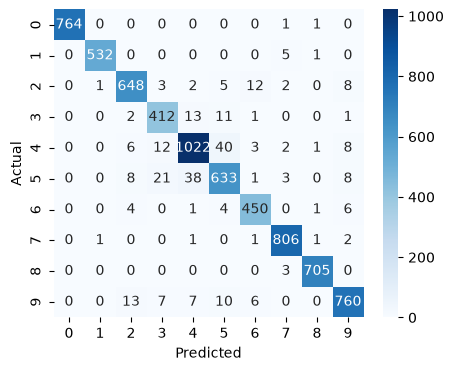

Acuratetea pentru LinearSVC() este: 0.9727920227920228
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       766
 Digital Cameras       1.00      1.00      1.00       538
     Dishwashers       0.95      0.98      0.96       681
        Freezers       0.98      0.97      0.97       440
 Fridge Freezers       0.97      0.95      0.96      1094
         Fridges       0.94      0.93      0.93       712
      Microwaves       0.99      0.97      0.98       466
   Mobile Phones       0.99      0.99      0.99       812
             TVs       0.97      1.00      0.98       708
Washing Machines       0.96      0.96      0.96       803

        accuracy                           0.97      7020
       macro avg       0.97      0.97      0.97      7020
    weighted avg       0.97      0.97      0.97      7020



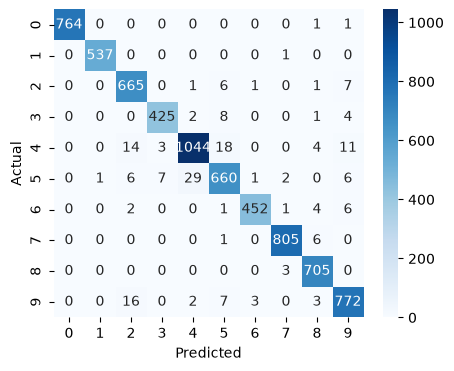

In [28]:
for i in lista_modele:
    model = i

    preprocessor = ColumnTransformer([
        ("tfidf", TfidfVectorizer(), "Product Title"),
        ("num", MinMaxScaler(), ["title_len_chars", "title_len_words", "has_digit", "longest_word_len"])
    ])

    pipeline = Pipeline([("features", preprocessor), ("classifier", model)])
    pipeline.fit(X_train, Y_train)
    
    Y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(Y_test, Y_pred)
    
    report = classification_report(Y_test, Y_pred)
    matrix = confusion_matrix(Y_test, Y_pred)
    
    print(f"Acuratetea pentru {i} este: {acc}")
    print(report)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,    
        fmt="d",        
        cmap="Blues",
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Rezultate și alegerea modelului final

**LinearSVC** obține cea mai bună acuratețe și cele mai bune scoruri F1 pe majoritatea categoriilor. Este de asemenea un model potrivit pentru date text sparse rezultate din TF-IDF (funcționează bine în spații de mari dimensiuni cu multe zero-uri). Categoriile cu cele mai multe confuzii sunt cele semantic apropiate — `Fridges`, `Fridge Freezers` și `Dishwashers` — unde precision/recall scad ușor sub restul categoriilor. Pe baza acestor rezultate, alegem **LinearSVC** ca model final, antrenat și salvat în `train_model.py`.

# Ingineria caracteristicilor

Pe lângă TF-IDF pe titlu, am testat adăugarea unor caracteristici numerice suplimentare derivate din titlu: lungimea în caractere, numărul de cuvinte, prezența cifrelor și lungimea celui mai lung cuvânt. Acestea au fost combinate cu TF-IDF printr-un `ColumnTransformer`.